In [14]:
import numpy as np
import soundfile as sf
from scipy.signal import resample
from sklearn.decomposition import FastICA

# Load both audio files
s1, sr1 = sf.read("/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/source_1.wav")
s2, sr2 = sf.read("/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/source_2.wav")

# Convert both to mono
s1_mono = s1.mean(axis=1) if s1.ndim > 1 else s1
s2_mono = s2.mean(axis=1) if s2.ndim > 1 else s2

# Resample if sample rates differ
if sr1 != sr2:
    print(f"Resampling s2 from {sr2} Hz to {sr1} Hz")
    num_samples = int(len(s2_mono) * sr1 / sr2)
    s2_mono = resample(s2_mono, num_samples)
    sr2 = sr1

# Now both are same sample rate
# Match lengths
max_len = max(len(s1_mono), len(s2_mono))
s1_pad = np.pad(s1_mono, (0, max_len - len(s1_mono)))
s2_pad = np.pad(s2_mono, (0, max_len - len(s2_mono)))

# Stack into (n_samples, 2)
S = np.stack([s1_pad, s2_pad], axis=1)

# Standardize (optional but helpful)
S /= S.std(axis=0)

# Create mixing matrix
A = np.array([[1, 0.5],
              [0.5, 1]])

# Mix the signals
X = np.dot(S, A.T)

# Save the mixed signals
sf.write("mixed1.wav", X[:, 0], sr1)
sf.write("mixed2.wav", X[:, 1], sr1)


Resampling s2 from 44100 Hz to 8000 Hz


In [15]:
ica = FastICA(n_components=2, random_state=0)
S_est = ica.fit_transform(X)  # Estimated source signals
A_est = ica.mixing_           # Estimated mixing matrix

# Save separated signals
sf.write("recovered1.wav", S_est[:, 0], sr1)
sf.write("recovered2.wav", S_est[:, 1], sr2)


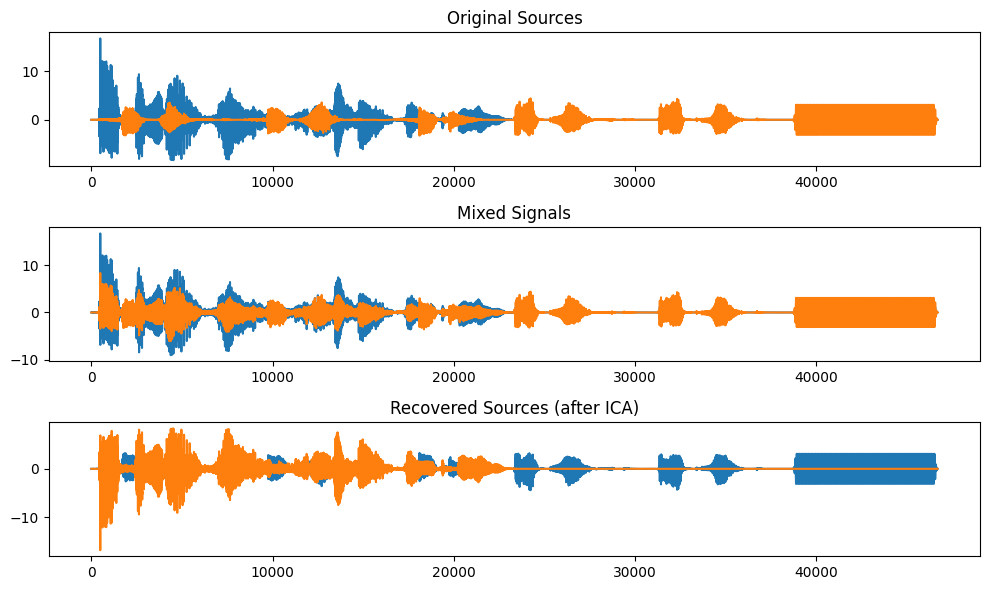

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.title("Original Sources")
plt.plot(S)

plt.subplot(3,1,2)
plt.title("Mixed Signals")
plt.plot(X)

plt.subplot(3,1,3)
plt.title("Recovered Sources (after ICA)")
plt.plot(S_est)
plt.tight_layout()
plt.show()


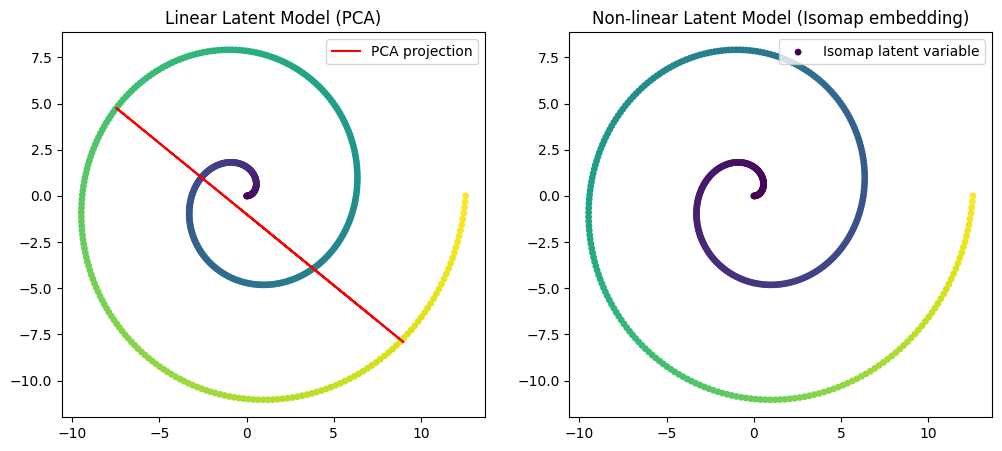

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

# Create nonlinear (spiral) data
t = np.linspace(0, 4 * np.pi, 500)
x = t * np.cos(t)
y = t * np.sin(t)
data = np.stack([x, y], axis=1)

# Apply linear PCA
pca = PCA(n_components=1)
pca_proj = pca.inverse_transform(pca.fit_transform(data))

# Apply nonlinear dimensionality reduction (Isomap as example)
iso = Isomap(n_components=1)
iso_emb = iso.fit_transform(data)

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], c=t, cmap="viridis", s=15)
plt.plot(pca_proj[:, 0], pca_proj[:, 1], color="red", label="PCA projection")
plt.title("Linear Latent Model (PCA)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(data[:, 0], data[:, 1], c=iso_emb[:, 0], cmap="viridis", s=15)
plt.title("Non-linear Latent Model (Isomap embedding)")
plt.legend(["Isomap latent variable"])

plt.show()
